In [10]:
import pandas as pd
import numpy as np
import seaborn as sns 
import time
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# 1. loading Features 
X_train = pd.read_csv("../LFB_project_data/baseline_data/X_train_final.csv")
X_test = pd.read_csv("../LFB_project_data/baseline_data/X_test_final.csv")

# 2. squeeze makes a series
y_train = pd.read_csv("../LFB_project_data/baseline_data/y_train.csv").squeeze()
y_test = pd.read_csv("../LFB_project_data/baseline_data/y_test.csv").squeeze()

# 3. Log targetfor training the models
y_train_log = pd.read_csv("../LFB_project_data/baseline_data/y_train_log.csv").squeeze()
y_test_log = pd.read_csv("../LFB_project_data/baseline_data/y_test_log.csv").squeeze()

print(f"data is loaded! X_train Shape: {X_train.shape}")

data is loaded! X_train Shape: (426881, 49)


In [ ]:

#Modelle definition

models_fast = {
    "Naive Baseline (Mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Random Forest (Simple)": RandomForestRegressor(n_estimators=50, max_depth=8, n_jobs=-1, random_state=42)
}

models_slow = {
    "KNN Regressor": KNeighborsRegressor(n_neighbors=10, n_jobs=-1) 
}

# 1. Funktion universal

def run_baselines(models_dict, X_train, X_test, y_train, y_test):
    all_results = []
    
    # y_test 
    y_test_original = np.expm1(y_test)
    
    for name, model in models_dict.items():
        print(f"⌛ Calculating {name}...")
        start = time.time()
        
        model.fit(X_train, y_train)
        y_pred_log = model.predict(X_test) # this are the log values
        
        duration = time.time() - start

        # calculation original values from the log values
        y_pred_original = np.expm1(y_pred_log) 
        
        all_results.append({
            "Model": name,
            "MAE": round(mean_absolute_error(y_test_original, y_pred_original), 2),
            "RMSE": round(np.sqrt(mean_squared_error(y_test_original, y_pred_original)), 2),
            "R2 Score": round(r2_score(y_test_original, y_pred_original), 4),
            "Dauer (sec)": round(duration, 2)
        })
    return pd.DataFrame(all_results)



In [6]:
# 2. run models

results_fast = run_baselines(models_fast, X_train, X_test, y_train_log, y_test_log)

results_slow = run_baselines(models_slow, X_train, X_test.iloc[:10000], y_train_log, y_test_log.iloc[:10000])

# 3. Output final results
final_results = pd.concat([results_fast, results_slow]).sort_values("MAE")
print(final_results)

⌛ Berechne Naive Baseline (Mean)...
⌛ Berechne Linear Regression...
⌛ Berechne Random Forest (Simple)...
⌛ Berechne KNN Regressor...
                    Model    MAE    RMSE  R2 Score  Dauer (sec)
2  Random Forest (Simple)  54.93   76.74    0.5100         9.91
1       Linear Regression  59.03   85.30    0.3946         0.38
0           KNN Regressor  63.28   84.39    0.3472         2.02
0   Naive Baseline (Mean)  86.43  112.88   -0.0601         0.00


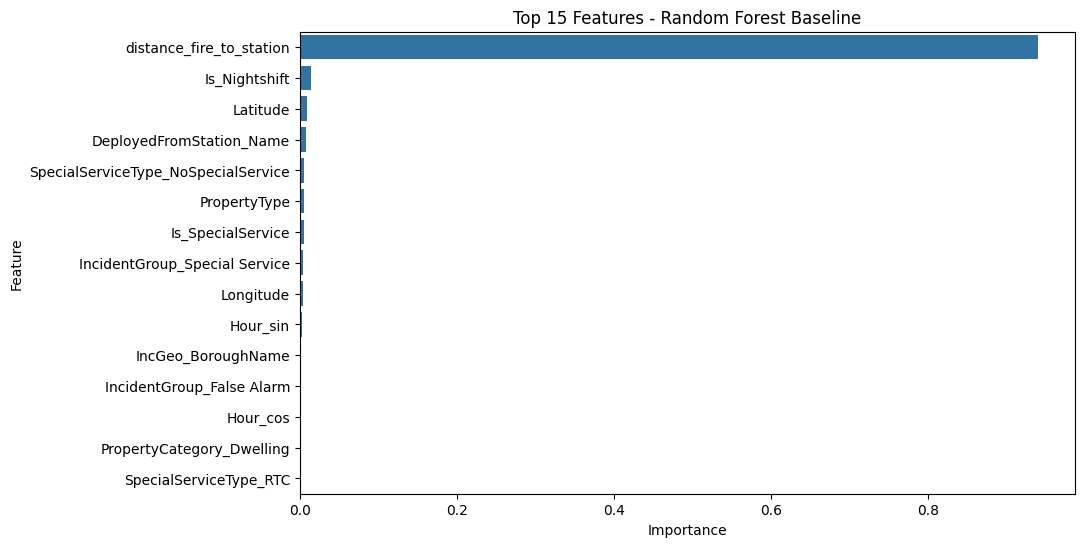

Top 5 most important features:
                                Feature  Importance
16             distance_fire_to_station    0.939938
7                         Is_Nightshift    0.013694
14                             Latitude    0.008836
46             DeployedFromStation_Name    0.008097
35  SpecialServiceType_NoSpecialService    0.005633


In [13]:
#get the best features
best_model = models_fast["Random Forest (Simple)"]
best_model.fit(X_train, y_train_log)


importances = best_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
plt.title('Top 15 Features - Random Forest Baseline')
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight') 
plt.show()

# 4. Text-Ausgabe der Top 5
print("Top 5 most important features:")
print(feature_importance_df.head(5))


In [12]:
print(X_train.shape)
print(X_test.shape)

(426881, 49)
(137825, 49)
